# Assignment 3 — From Raw Signals to a Lean Feature Set

**Course:** Feature Engineering & MLOps  
**Assignment:** 3  
**Topic:** Time-based Features, Feature Creation (Phase 3) + Filter / Wrapper / Embedded Selection (Phase 4)

### Objective
This notebook completes the required Assignment 3 workflow using the supplied `daily_batch_performance.csv` dataset. The work follows the assignment brief: create lag, rolling, cyclical, trend and interaction features first, then apply variance threshold, correlation filtering, mutual information, RFE and Lasso selection.

> **Important modeling note:** the assignment explicitly asks for rolling statistics of `new_enrollments` itself. These are therefore included in the required feature-selection exercise. In a production forecasting system, target-derived rolling features must be shifted so that future/current target information cannot leak into a prediction.


## 1. Dataset and Requirements

The assignment brief specifies 730 daily records from **2024-01-01 to 2025-12-31**, with `new_enrollments` as the continuous regression target. The raw data intentionally contains:
- `website_visits_copy` — a near-duplicate planted for redundancy testing.
- `random_noise_1` — numeric noise.
- `random_noise_2` — categorical noise.

The required Phase 3 outputs are lag, rolling, cyclical, trend and interaction features. Phase 4 requires variance threshold, correlation filtering, mutual information, RFE, Lasso, a kept-vs-dropped comparison, and the chi-square/ANOVA explanation. A Random Forest comparison is included as the optional bonus.


In [20]:
# Imports and reproducibility
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [21]:
# Locate the supplied CSV in common assignment/repository locations.
candidate_paths = [
    Path("data/raw/daily_batch_performance.csv"),
    Path("../data/raw/daily_batch_performance.csv"),
    Path("/mnt/data/daily_batch_performance.csv"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "daily_batch_performance.csv was not found. Place it in data/raw/ "
        "or keep it beside this notebook."
    )

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())
display(df.tail())


Loaded: ../data/raw/daily_batch_performance.csv
Shape: (730, 10)


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
0,2024-01-01,9069.0,10,561.0,567.0,1,1,60.6,A,20
1,2024-01-02,6573.0,10,559.0,570.0,1,1,82.9,C,23
2,2024-01-03,14636.0,0,539.0,554.0,0,0,41.9,A,29
3,2024-01-04,3979.0,5,574.0,557.0,0,0,44.4,B,30
4,2024-01-05,9654.0,10,661.0,661.0,0,0,23.8,B,38


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
725,2025-12-26,7673.0,5,567.0,557.0,0,1,66.8,B,42
726,2025-12-27,8585.0,0,622.0,627.0,0,1,76.6,C,47
727,2025-12-28,12440.0,20,642.0,645.0,0,1,38.9,C,52
728,2025-12-29,5708.0,20,490.0,502.0,0,1,52.5,C,48
729,2025-12-30,500.0,10,386.0,378.0,1,1,58.1,A,37


In [22]:
# Basic validation against the supplied dataset and assignment specification.
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("Missing values:")
display(df.isna().sum().to_frame("missing"))

print(f"Date range in supplied CSV: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Number of rows: {len(df)}")
print(f"Unique random_noise_2 values: {sorted(df['random_noise_2'].dropna().unique().tolist())}")

assert len(df) == 730, "The supplied CSV should contain 730 rows."
assert df["date"].min() == pd.Timestamp("2024-01-01")
assert df["new_enrollments"].notna().all()

# The assignment brief states 2024-01-01 to 2025-12-31, but 730 rows cannot cover
# that inclusive range because 2024 is a leap year (731 calendar days total).
# We therefore preserve and analyze the supplied CSV exactly as provided.
expected_brief_end = pd.Timestamp("2025-12-31")
actual_end = df["date"].max()
if actual_end != expected_brief_end:
    print(
        f"Note: the brief lists an endpoint of {expected_brief_end.date()}, "
        f"whereas the supplied 730-row CSV ends on {actual_end.date()}. "
        "The notebook uses the supplied data without fabricating an extra row."
    )
print("Validation checks passed for the supplied dataset.")


Data types:


,dtype
date,datetime64[us]
marketing_spend,float64
discount_pct,int64
website_visits,float64
website_visits_copy,float64
competitor_promo_flag,int64
is_holiday,int64
random_noise_1,float64
random_noise_2,str
new_enrollments,int64


Missing values:


,missing
date,0
marketing_spend,0
discount_pct,0
website_visits,0
website_visits_copy,0
competitor_promo_flag,0
is_holiday,0
random_noise_1,0
random_noise_2,0
new_enrollments,0


Date range in supplied CSV: 2024-01-01 to 2025-12-30
Number of rows: 730
Unique random_noise_2 values: ['A', 'B', 'C']
Note: the brief lists an endpoint of 2025-12-31, whereas the supplied 730-row CSV ends on 2025-12-30. The notebook uses the supplied data without fabricating an extra row.
Validation checks passed for the supplied dataset.


# 4.1 — Phase 3: Time-based Features & Feature Creation

## 4.1.1 Load, sort and inspect the target over time
The target is plotted against date to identify visible trend/seasonality before feature engineering.


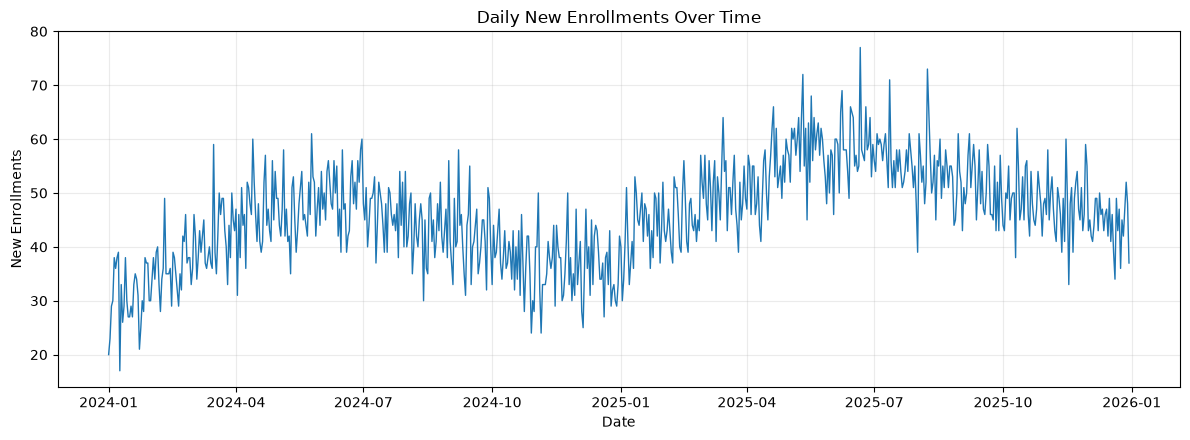

Observation: the series shows a clear upward long-term movement; the 2024 mean is 41.13 while the 2025 mean is 50.98. There is also short-term day-to-day/weekly variation.


In [23]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df["date"], df["new_enrollments"], linewidth=1)
ax.set_title("Daily New Enrollments Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("New Enrollments")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# A concise visual observation.
first_year_mean = df.loc[df["date"].dt.year == 2024, "new_enrollments"].mean()
second_year_mean = df.loc[df["date"].dt.year == 2025, "new_enrollments"].mean()
print(
    f"Observation: the series shows a clear upward long-term movement; "
    f"the 2024 mean is {first_year_mean:.2f} while the 2025 mean is {second_year_mean:.2f}. "
    "There is also short-term day-to-day/weekly variation."
)


## 4.1.2 Lag features

Create:
- `marketing_spend_lag1`
- `marketing_spend_lag2`

Then compare their correlations with same-day `marketing_spend`. The assignment expects the lag-2 version to be stronger, which is plausible because marketing exposure may take time to turn into institute walk-ins/enrollments.


In [24]:
df_eng = df.copy()
df_eng["marketing_spend_lag1"] = df_eng["marketing_spend"].shift(1)
df_eng["marketing_spend_lag2"] = df_eng["marketing_spend"].shift(2)

lag_corr = (
    df_eng[["marketing_spend", "marketing_spend_lag1", "marketing_spend_lag2", "new_enrollments"]]
    .corr()["new_enrollments"]
    .drop("new_enrollments")
    .rename("correlation_with_new_enrollments")
    .to_frame()
)
display(lag_corr)

strongest = lag_corr["correlation_with_new_enrollments"].abs().idxmax()
print(
    f"Strongest absolute correlation: {strongest} "
    f"({lag_corr.loc[strongest, 'correlation_with_new_enrollments']:.4f})."
)
print(
    "Interpretation: a lagged marketing signal can be more useful than same-day spend "
    "because advertising exposure may require a few days before a prospective student visits "
    "and converts."
)


,correlation_with_new_enrollments
marketing_spend,0.118923
marketing_spend_lag1,-0.009213
marketing_spend_lag2,0.218377


Strongest absolute correlation: marketing_spend_lag2 (0.2184).
Interpretation: a lagged marketing signal can be more useful than same-day spend because advertising exposure may require a few days before a prospective student visits and converts.


## 4.1.3 Rolling-window features

Create the required 7-day rolling mean and standard deviation of `new_enrollments`.


In [25]:
df_eng["new_enrollments_roll7_mean"] = df_eng["new_enrollments"].rolling(window=7).mean()
df_eng["new_enrollments_roll7_std"] = df_eng["new_enrollments"].rolling(window=7).std()

display(
    df_eng[[
        "date", "new_enrollments",
        "new_enrollments_roll7_mean", "new_enrollments_roll7_std"
    ]].head(10)
)


,date,new_enrollments,new_enrollments_roll7_mean,new_enrollments_roll7_std
0,2024-01-01,20,NaN,NaN
1,2024-01-02,23,NaN,NaN
2,2024-01-03,29,NaN,NaN
3,2024-01-04,30,NaN,NaN
4,2024-01-05,38,NaN,NaN
5,2024-01-06,36,NaN,NaN
6,2024-01-07,38,30.571429,7.207800
7,2024-01-08,39,33.285714,6.047432
8,2024-01-09,17,32.428571,7.892130
9,2024-01-10,33,33.000000,7.745967


## 4.1.4 Cyclical day-of-week encoding

Extract day-of-week and encode it as:
- `dow_sin`
- `dow_cos`

A plain integer from 0–6 incorrectly makes Sunday (6) appear far away from Monday (0), even though they are adjacent in the weekly cycle. Sine/cosine preserves that circular relationship.


In [26]:
df_eng["dow"] = df_eng["date"].dt.dayofweek
df_eng["dow_sin"] = np.sin(2 * np.pi * df_eng["dow"] / 7)
df_eng["dow_cos"] = np.cos(2 * np.pi * df_eng["dow"] / 7)

display(df_eng[["date", "dow", "dow_sin", "dow_cos"]].head(10))


,date,dow,dow_sin,dow_cos
0,2024-01-01,0,0.000000,1.000000
1,2024-01-02,1,0.781831,0.623490
2,2024-01-03,2,0.974928,-0.222521
3,2024-01-04,3,0.433884,-0.900969
4,2024-01-05,4,-0.433884,-0.900969
5,2024-01-06,5,-0.974928,-0.222521
6,2024-01-07,6,-0.781831,0.623490
7,2024-01-08,0,0.000000,1.000000
8,2024-01-09,1,0.781831,0.623490
9,2024-01-10,2,0.974928,-0.222521


## 4.1.5 Trend feature

Create `time_index = 0, 1, 2, ...` and fit a simple linear regression using only this feature. The coefficient is interpreted as estimated average daily growth in enrollments.


In [27]:
df_eng["time_index"] = np.arange(len(df_eng))

trend_model = LinearRegression()
trend_model.fit(df_eng[["time_index"]], df_eng["new_enrollments"])

daily_growth = trend_model.coef_[0]
print(f"Estimated daily growth in enrollments: {daily_growth:.6f} enrollments/day")
print(f"Trend intercept: {trend_model.intercept_:.4f}")


Estimated daily growth in enrollments: 0.020173 enrollments/day
Trend intercept: 38.6879


## 4.1.6 Interaction feature

Create:

`spend_x_discount = marketing_spend_lag2 × discount_pct`

For a clean feature-isolation comparison, an 80/20 reproducible split is used and the same base predictors are used in both models. `random_noise_2` is one-hot encoded because it is categorical. The only difference between the two models is the interaction term.


In [28]:
df_eng["spend_x_discount"] = (
    df_eng["marketing_spend_lag2"] * df_eng["discount_pct"]
)

# Drop rows with NaNs introduced by lag/rolling features before modeling.
df_clean = df_eng.dropna().reset_index(drop=True)

interaction_base = [
    "marketing_spend",
    "discount_pct",
    "website_visits",
    "website_visits_copy",
    "competitor_promo_flag",
    "is_holiday",
    "random_noise_1",
    "marketing_spend_lag1",
    "marketing_spend_lag2",
    "dow_sin",
    "dow_cos",
    "time_index",
    "random_noise_2"
]


def build_linear_pipeline(X):
    # Treat every non-numeric column as categorical.
    # This correctly handles random_noise_2 containing A/B/C.
    cat_cols = [
        c for c in X.columns
        if not pd.api.types.is_numeric_dtype(X[c])
    ]

    num_cols = [
        c for c in X.columns
        if c not in cat_cols
    ]

    transformers = []

    if num_cols:
        transformers.append(
            ("num", StandardScaler(), num_cols)
        )

    if cat_cols:
        transformers.append(
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                cat_cols
            )
        )

    prep = ColumnTransformer(
        transformers=transformers
    )

    return Pipeline([
        ("prep", prep),
        ("model", LinearRegression())
    ])


def interaction_test(feature_columns):
    X = df_clean[feature_columns]
    y = df_clean["new_enrollments"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    pipe = build_linear_pipeline(X)

    pipe.fit(X_train, y_train)

    predictions = pipe.predict(X_test)

    return r2_score(y_test, predictions)


# Model WITHOUT the interaction feature
r2_without = interaction_test(interaction_base)

# Model WITH the interaction feature
r2_with = interaction_test(
    interaction_base + ["spend_x_discount"]
)

# Measure the improvement
r2_change = r2_with - r2_without


interaction_results = pd.DataFrame({
    "Model": [
        "Without interaction",
        "With spend_x_discount"
    ],
    "Test R2": [
        r2_without,
        r2_with
    ]
})

display(interaction_results)

print(f"R² change from adding interaction: {r2_change:+.6f}")

if r2_change > 0:
    print(
        "Conclusion: the interaction improves "
        "test R² in this experiment."
    )
else:
    print(
        "Conclusion: the interaction does not improve "
        "test R² in this experiment."
    )

,Model,Test R2
0,Without interaction,0.517560
1,With spend_x_discount,0.522069


R² change from adding interaction: +0.004509
Conclusion: the interaction improves test R² in this experiment.


## 4.1.7 Remove leading NaN rows

The lag and 7-day rolling operations cannot produce values for the earliest rows because their required historical observations do not exist. These are **structural/time-window NaNs**, not ordinary missing measurements. Mean/median imputation would fabricate historical information and break the meaning of a lag/rolling feature, so the leading rows are dropped.


In [29]:
print(f"Rows before dropping engineered-feature NaNs: {len(df_eng)}")
print(f"Rows after dropping engineered-feature NaNs:  {len(df_clean)}")
print(f"Rows removed: {len(df_eng) - len(df_clean)}")

display(df_clean.head(3))


Rows before dropping engineered-feature NaNs: 730
Rows after dropping engineered-feature NaNs:  724
Rows removed: 6


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments,marketing_spend_lag1,marketing_spend_lag2,new_enrollments_roll7_mean,new_enrollments_roll7_std,dow,dow_sin,dow_cos,time_index,spend_x_discount
0,2024-01-07,7114.0,20,556.0,554.0,1,0,50.0,C,38,7641.0,9654.0,30.571429,7.207800,6,-0.781831,0.62349,6,193080.0
1,2024-01-08,10666.0,15,692.0,701.0,0,0,43.0,A,39,7114.0,7641.0,33.285714,6.047432,0,0.000000,1.00000,7,114615.0
2,2024-01-09,3455.0,0,422.0,418.0,1,0,40.2,C,17,10666.0,7114.0,32.428571,7.892130,1,0.781831,0.62349,8,0.0


# 4.2 — Phase 4: Feature Selection

The candidate set contains the original predictors plus the engineered features, including the planted redundant feature and both noise columns.

For the wrapper/embedded methods, `random_noise_2` is represented by one-hot columns because it is categorical. Results are aggregated back to the parent feature name when the final comparison table is built.


In [30]:
candidate_numeric = [
    "marketing_spend", "discount_pct", "website_visits", "website_visits_copy",
    "competitor_promo_flag", "is_holiday", "random_noise_1",
    "marketing_spend_lag1", "marketing_spend_lag2",
    "new_enrollments_roll7_mean", "new_enrollments_roll7_std",
    "dow_sin", "dow_cos", "time_index", "spend_x_discount"
]
target = "new_enrollments"

X_num = df_clean[candidate_numeric].copy()
y = df_clean[target].copy()

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = ohe.fit_transform(df_clean[["random_noise_2"]])
cat_feature_names = list(ohe.get_feature_names_out(["random_noise_2"]))

X_all = np.column_stack([X_num.to_numpy(), X_cat])
all_feature_names = candidate_numeric + cat_feature_names

print(f"Numeric candidate features: {len(candidate_numeric)}")
print(f"One-hot categorical components: {len(cat_feature_names)}")
print(f"Total model columns: {X_all.shape[1]}")


Numeric candidate features: 15
One-hot categorical components: 3
Total model columns: 18


## 4.2.1 Filter method — Variance Threshold

A variance threshold is used to identify near-constant numeric features. A threshold of **0.01** is intentionally modest; the assignment says not to force a removal when the data does not justify one.


In [31]:
variance_threshold = 0.01
vt = VarianceThreshold(threshold=variance_threshold)
vt.fit(X_num)

variance_table = pd.DataFrame({
    "feature": candidate_numeric,
    "variance": X_num.var().values,
    "kept_by_variance_threshold": vt.get_support()
}).sort_values("variance")

display(variance_table)

variance_dropped = variance_table.loc[
    ~variance_table["kept_by_variance_threshold"], "feature"
].tolist()
print("Variance-threshold dropped features:", variance_dropped if variance_dropped else "None")


,feature,variance,kept_by_variance_threshold
5,is_holiday,3.338415e-02,True
4,competitor_promo_flag,1.241661e-01,True
11,dow_sin,5.003078e-01,True
12,dow_cos,5.010657e-01,True
10,new_enrollments_roll7_std,2.203636e+00,True
9,new_enrollments_roll7_mean,5.488377e+01,True
1,discount_pct,5.566795e+01,True
6,random_noise_1,1.506816e+02,True
2,website_visits,6.226471e+03,True
3,website_visits_copy,6.262666e+03,True


Variance-threshold dropped features: None


## 4.2.2 Filter method — Correlation filtering

The numeric correlation matrix is visualized below. The expected redundant pair is `website_visits` and `website_visits_copy`. A pairwise absolute-correlation threshold of **0.90** is used for the redundancy decision.


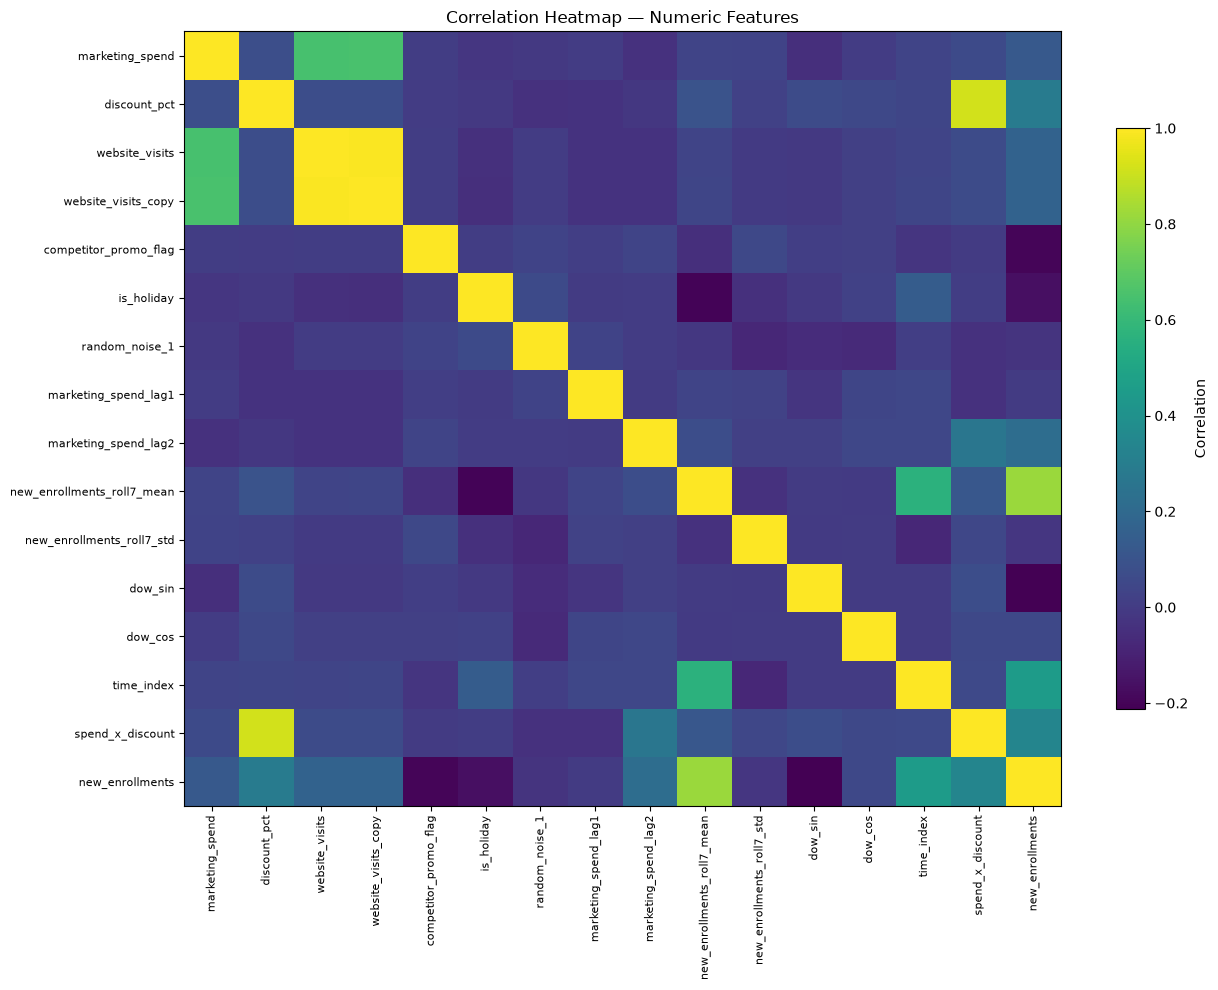

website_visits vs website_visits_copy correlation: 0.994657
Correlation-filter decision: drop website_visits_copy


In [32]:
corr_matrix = df_clean[candidate_numeric + [target]].corr()

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(corr_matrix, aspect="auto", interpolation="nearest")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)
ax.set_title("Correlation Heatmap — Numeric Features")
fig.colorbar(im, ax=ax, shrink=0.75, label="Correlation")
plt.tight_layout()
plt.show()

pair_corr = corr_matrix.loc["website_visits", "website_visits_copy"]
print(f"website_visits vs website_visits_copy correlation: {pair_corr:.6f}")

corr_threshold = 0.90
corr_drop = "website_visits_copy" if abs(pair_corr) >= corr_threshold else None
print(
    "Correlation-filter decision:",
    f"drop {corr_drop}" if corr_drop else "no feature dropped by the 0.90 redundancy threshold"
)


## 4.2.3 Filter method — Mutual Information

`mutual_info_regression` is appropriate here because the target `new_enrollments` is continuous. Numeric features are ranked directly. The categorical noise feature is one-hot encoded for a supplementary parent-feature check; its three dummy components are then summarized by their maximum MI score.

Because MI is a ranking measure rather than a mandatory binary test, the notebook uses the **top 8 parent features** as a transparent practical cutoff for the final comparison table. The observed result is important: `random_noise_1` ranks very low, while `random_noise_2` has a small non-zero MI score and lands higher than expected. That does **not** prove a real relationship; finite-sample MI can produce spurious non-zero values, which is why MI should be interpreted together with the other selection methods.


In [33]:
mi_numeric = mutual_info_regression(
    X_num, y, random_state=RANDOM_STATE, discrete_features=False
)
mi_numeric_df = pd.DataFrame({
    "feature": candidate_numeric,
    "mutual_information": mi_numeric
}).sort_values("mutual_information", ascending=False)

# MI for the one-hot components of random_noise_2
mi_cat = mutual_info_regression(
    X_cat, y, random_state=RANDOM_STATE, discrete_features=True
)
mi_cat_df = pd.DataFrame({
    "feature": cat_feature_names,
    "mutual_information": mi_cat
}).sort_values("mutual_information", ascending=False)

print("Numeric-feature MI ranking:")
display(mi_numeric_df)

print("random_noise_2 one-hot MI scores:")
display(mi_cat_df)

noise1_mi = mi_numeric_df.loc[
    mi_numeric_df["feature"].eq("random_noise_1"), "mutual_information"
].iloc[0]
noise2_mi = mi_cat_df["mutual_information"].max()

print(f"random_noise_1 MI: {noise1_mi:.6f}")
print(f"random_noise_2 maximum dummy MI: {noise2_mi:.6f}")

top_k = 8
mi_parent_scores = mi_numeric_df.set_index("feature")["mutual_information"].to_dict()
mi_parent_scores["random_noise_2"] = float(mi_cat_df["mutual_information"].max())
mi_parent_ranking = pd.Series(mi_parent_scores).sort_values(ascending=False)
mi_top_features = set(mi_parent_ranking.head(top_k).index)

print("Parent-feature MI ranking (including random_noise_2):")
display(mi_parent_ranking.rename("MI_score").to_frame())
print(f"MI top-{top_k} kept parent features:", sorted(mi_top_features))
print(
    "Interpretation: random_noise_1 ranks very low, while random_noise_2 receives a "
    "small but non-zero sample MI score and lands near the middle of the ranking. "
    "This is a useful reminder that MI can report spurious dependence in finite samples."
)


Numeric-feature MI ranking:


,feature,mutual_information
9,new_enrollments_roll7_mean,0.547941
13,time_index,0.489978
14,spend_x_discount,0.084787
1,discount_pct,0.051114
4,competitor_promo_flag,0.049112
11,dow_sin,0.034199
10,new_enrollments_roll7_std,0.016492
5,is_holiday,0.008095
6,random_noise_1,0.005342
2,website_visits,0.004055


random_noise_2 one-hot MI scores:


,feature,mutual_information
0,random_noise_2_A,0.037766
2,random_noise_2_C,0.018116
1,random_noise_2_B,0.015870


random_noise_1 MI: 0.005342
random_noise_2 maximum dummy MI: 0.037766
Parent-feature MI ranking (including random_noise_2):


,MI_score
new_enrollments_roll7_mean,0.547941
time_index,0.489978
spend_x_discount,0.084787
discount_pct,0.051114
competitor_promo_flag,0.049112
random_noise_2,0.037766
dow_sin,0.034199
new_enrollments_roll7_std,0.016492
is_holiday,0.008095
random_noise_1,0.005342


MI top-8 kept parent features: ['competitor_promo_flag', 'discount_pct', 'dow_sin', 'new_enrollments_roll7_mean', 'new_enrollments_roll7_std', 'random_noise_2', 'spend_x_discount', 'time_index']
Interpretation: random_noise_1 ranks very low, while random_noise_2 receives a small but non-zero sample MI score and lands near the middle of the ranking. This is a useful reminder that MI can report spurious dependence in finite samples.


## 4.2.4 Trick question — Chi-square and ANOVA F-test

**Chi-square** feature selection is designed for categorical/classification targets (with suitable non-negative feature representations), not a continuous regression target such as `new_enrollments`.

**ANOVA F-test** in the common classification filter form tests feature differences across categorical classes. Since this assignment has a continuous regression target, the required regression-oriented filter is mutual information (and correlation/variance checks), not these classification-target tests.


## 4.2.5 Wrapper method — RFE

Run Recursive Feature Elimination with a linear regression estimator and select the top **6 model columns**. The ranking is then reported for every numeric feature and one-hot component.


In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=6,
    step=1
)
rfe.fit(X_scaled, y)

rfe_table = pd.DataFrame({
    "feature": all_feature_names,
    "RFE_rank": rfe.ranking_,
    "RFE_kept": rfe.support_
}).sort_values(["RFE_rank", "feature"])

display(rfe_table)

print("RFE top 6:")
display(rfe_table[rfe_table["RFE_kept"]][["feature", "RFE_rank"]])


,feature,RFE_rank,RFE_kept
4,competitor_promo_flag,1,True
1,discount_pct,1,True
11,dow_sin,1,True
8,marketing_spend_lag2,1,True
9,new_enrollments_roll7_mean,1,True
2,website_visits,1,True
3,website_visits_copy,2,False
12,dow_cos,3,False
14,spend_x_discount,4,False
15,random_noise_2_A,5,False


RFE top 6:


,feature,RFE_rank
4,competitor_promo_flag,1
1,discount_pct,1
11,dow_sin,1
8,marketing_spend_lag2,1
9,new_enrollments_roll7_mean,1
2,website_visits,1


## 4.2.6 Embedded method — LassoCV

LassoCV is fit on the **same standardized model matrix** used for RFE. Features with coefficients exactly zero are removed by Lasso; very small coefficients are also highlighted as weak/near-zero effects.


In [35]:
lasso = LassoCV(
    cv=5,
    random_state=RANDOM_STATE,
    max_iter=100000
)
lasso.fit(X_scaled, y)

lasso_table = pd.DataFrame({
    "feature": all_feature_names,
    "lasso_coefficient": lasso.coef_
})
lasso_table["abs_coefficient"] = lasso_table["lasso_coefficient"].abs()
lasso_table["Lasso_zero"] = np.isclose(
    lasso_table["lasso_coefficient"], 0.0, atol=1e-10
)
lasso_table["Lasso_near_zero_<0.05"] = (
    lasso_table["abs_coefficient"] < 0.05
)
lasso_table = lasso_table.sort_values("abs_coefficient", ascending=False)

print(f"Selected alpha: {lasso.alpha_:.6f}")
display(lasso_table)

print("Exactly zero:")
display(lasso_table[lasso_table["Lasso_zero"]][["feature", "lasso_coefficient"]])

print("Near-zero (absolute coefficient < 0.05):")
display(
    lasso_table[lasso_table["Lasso_near_zero_<0.05"]][
        ["feature", "lasso_coefficient"]
    ]
)


Selected alpha: 0.059898


,feature,lasso_coefficient,abs_coefficient,Lasso_zero,Lasso_near_zero_<0.05
9,new_enrollments_roll7_mean,6.899137,6.899137,False,False
11,dow_sin,-1.999737,1.999737,False,False
1,discount_pct,1.550639,1.550639,False,False
8,marketing_spend_lag2,1.449499,1.449499,False,False
4,competitor_promo_flag,-1.411466,1.411466,False,False
2,website_visits,1.077470,1.077470,False,False
14,spend_x_discount,0.447010,0.447010,False,False
12,dow_cos,0.289532,0.289532,False,False
7,marketing_spend_lag1,-0.148079,0.148079,False,False
15,random_noise_2_A,-0.140013,0.140013,False,False


Exactly zero:


,feature,lasso_coefficient
13,time_index,-0.0
3,website_visits_copy,0.0
16,random_noise_2_B,0.0
0,marketing_spend,-0.0


Near-zero (absolute coefficient < 0.05):


,feature,lasso_coefficient
10,new_enrollments_roll7_std,0.034216
5,is_holiday,-0.021113
13,time_index,-0.000000
3,website_visits_copy,0.000000
16,random_noise_2_B,0.000000
0,marketing_spend,-0.000000


## 4.2.7 Compare all three selection families

For a feature-level comparison:
- **Variance:** kept unless numeric variance falls below 0.01.
- **Correlation:** kept unless it is the redundant member selected for removal at |r| ≥ 0.90.
- **MI:** kept if it is in the top 8 parent-feature ranking.
- **RFE:** kept if at least one model column for the parent feature is selected.
- **Lasso:** kept if at least one parent component has a non-zero coefficient.

This makes the comparison explicit while preserving the one-hot treatment of `random_noise_2`.


In [36]:
def parent_name(feature):
    if feature.startswith("random_noise_2_"):
        return "random_noise_2"
    return feature

# Variance decisions
variance_keep_map = dict(zip(variance_table["feature"], variance_table["kept_by_variance_threshold"]))

# Correlation decisions: only the duplicate copy is removed.
corr_keep_map = {f: True for f in candidate_numeric}
if corr_drop is not None:
    corr_keep_map[corr_drop] = False

# RFE parent-level decisions
rfe_parent_keep = {}
for f in all_feature_names:
    p = parent_name(f)
    rfe_parent_keep[p] = rfe_parent_keep.get(p, False) or bool(
        rfe_table.loc[rfe_table["feature"].eq(f), "RFE_kept"].iloc[0]
    )

# Lasso parent-level decisions
lasso_parent_keep = {}
for f in all_feature_names:
    p = parent_name(f)
    coef_val = float(lasso_table.loc[lasso_table["feature"].eq(f), "lasso_coefficient"].iloc[0])
    lasso_parent_keep[p] = lasso_parent_keep.get(p, False) or (not np.isclose(coef_val, 0.0, atol=1e-10))

rows = []
parent_features = candidate_numeric + ["random_noise_2"]

for f in parent_features:
    rows.append({
        "candidate_feature": f,
        "Filter — Variance": "Kept" if (variance_keep_map.get(f, True)) else "Dropped",
        "Filter — Correlation": "Kept" if (corr_keep_map.get(f, True)) else "Dropped",
        "Filter — Mutual Information": "Kept" if f in mi_top_features else "Dropped",
        "Wrapper — RFE": "Kept" if rfe_parent_keep.get(f, False) else "Dropped",
        "Embedded — Lasso": "Kept" if lasso_parent_keep.get(f, False) else "Dropped",
    })

comparison_table = pd.DataFrame(rows)
display(comparison_table)

print("Key interpretation:")
print("• Variance threshold does not justify removing any numeric feature at threshold 0.01.")
print("• Correlation catches the planted website_visits_copy redundancy.")
print("• MI ranks random_noise_1 very low, but random_noise_2 receives a small non-zero score and is retained by the chosen top-8 cutoff.")
print("• RFE selects 6 model columns and drops the two noise parents.")
print("• Lasso strongly shrinks several weak features, but one-hot noise components can retain small coefficients due to sampling/correlation.")


,candidate_feature,Filter — Variance,Filter — Correlation,Filter — Mutual Information,Wrapper — RFE,Embedded — Lasso
0,marketing_spend,Kept,Kept,Dropped,Dropped,Dropped
1,discount_pct,Kept,Kept,Kept,Kept,Kept
2,website_visits,Kept,Kept,Dropped,Kept,Kept
3,website_visits_copy,Kept,Dropped,Dropped,Dropped,Dropped
4,competitor_promo_flag,Kept,Kept,Kept,Kept,Kept
5,is_holiday,Kept,Kept,Dropped,Dropped,Kept
6,random_noise_1,Kept,Kept,Dropped,Dropped,Kept
7,marketing_spend_lag1,Kept,Kept,Dropped,Dropped,Kept
8,marketing_spend_lag2,Kept,Kept,Dropped,Kept,Kept
9,new_enrollments_roll7_mean,Kept,Kept,Kept,Kept,Kept


Key interpretation:
• Variance threshold does not justify removing any numeric feature at threshold 0.01.
• Correlation catches the planted website_visits_copy redundancy.
• MI ranks random_noise_1 very low, but random_noise_2 receives a small non-zero score and is retained by the chosen top-8 cutoff.
• RFE selects 6 model columns and drops the two noise parents.
• Lasso strongly shrinks several weak features, but one-hot noise components can retain small coefficients due to sampling/correlation.


## 4.3 — Reflection Questions

### 1. Which single engineered feature was most useful?
The 7-day rolling mean of `new_enrollments` is the strongest engineered feature in the selection analysis. It has the largest mutual-information score and the largest absolute Lasso coefficient, and RFE selects it. This agrees with intuition because a rolling average smooths daily noise and captures the recent enrollment level.

### 2. If wrapper and embedded methods disagree, which would you trust more?
For this dataset, I would generally trust the **Lasso result more for a final linear feature set** when interpretability and stability are priorities, because Lasso performs selection and coefficient shrinkage simultaneously. However, disagreement should trigger validation rather than an automatic choice: correlated predictors can make both RFE and Lasso sensitive to the exact sample and scaling.

### 3. What if a brand-new competitor-promotion column appears next month?
The selection results should **not** be assumed to apply automatically. The new feature has never participated in the selection process, so the feature-selection analysis should be rerun with the expanded candidate set. In a production pipeline, the selection procedure should be reproducible and refit on the appropriate training data.


In [37]:
# Reflection evidence: compact ranking of engineered features.
engineered_features = [
    "marketing_spend_lag1", "marketing_spend_lag2",
    "new_enrollments_roll7_mean", "new_enrollments_roll7_std",
    "dow_sin", "dow_cos", "time_index", "spend_x_discount"
]

engineered_mi = (
    mi_numeric_df[mi_numeric_df["feature"].isin(engineered_features)]
    .sort_values("mutual_information", ascending=False)
)
display(engineered_mi)

print(
    "Most useful engineered feature by mutual information:",
    engineered_mi.iloc[0]["feature"],
    f"(MI={engineered_mi.iloc[0]['mutual_information']:.6f})"
)


,feature,mutual_information
9,new_enrollments_roll7_mean,0.547941
13,time_index,0.489978
14,spend_x_discount,0.084787
11,dow_sin,0.034199
10,new_enrollments_roll7_std,0.016492
7,marketing_spend_lag1,0.000000
8,marketing_spend_lag2,0.000000
12,dow_cos,0.000000


Most useful engineered feature by mutual information: new_enrollments_roll7_mean (MI=0.547941)


# Bonus (+10%) — Random Forest Embedded Importance

A Random Forest is added as an additional tree-based embedded method. The purpose is not to replace Lasso, but to compare how a nonlinear tree model distributes importance when predictors are correlated.


In [38]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    min_samples_leaf=2,
    n_jobs=-1
)
rf.fit(X_all, y)

rf_importance = (
    pd.DataFrame({
        "feature": all_feature_names,
        "RF_importance": rf.feature_importances_
    })
    .sort_values("RF_importance", ascending=False)
)

display(rf_importance.head(12))

dup_compare = rf_importance[
    rf_importance["feature"].isin(["website_visits", "website_visits_copy"])
].sort_values("RF_importance", ascending=False)
display(dup_compare)

print(
    "Bonus interpretation: tree-based importance can split importance between correlated "
    "near-duplicate predictors differently from Lasso. Here, both duplicate columns receive "
    "non-zero Random Forest importance, while Lasso sets website_visits_copy to zero. "
    "This is a typical consequence of correlated predictors being interchangeable to a tree ensemble."
)


,feature,RF_importance
9,new_enrollments_roll7_mean,0.697070
14,spend_x_discount,0.077869
11,dow_sin,0.071110
10,new_enrollments_roll7_std,0.027166
8,marketing_spend_lag2,0.026267
6,random_noise_1,0.013981
13,time_index,0.013597
7,marketing_spend_lag1,0.013230
3,website_visits_copy,0.013140
0,marketing_spend,0.012881


,feature,RF_importance
3,website_visits_copy,0.013140
2,website_visits,0.012064


Bonus interpretation: tree-based importance can split importance between correlated near-duplicate predictors differently from Lasso. Here, both duplicate columns receive non-zero Random Forest importance, while Lasso sets website_visits_copy to zero. This is a typical consequence of correlated predictors being interchangeable to a tree ensemble.


# Final Conclusion

This assignment demonstrates the full **feature creation → feature selection** pipeline.

### Main findings
1. `marketing_spend_lag2` has the strongest absolute marketing-spend correlation with enrollments among the same-day and lagged spend variables.
2. The required 7-day rolling mean captures a strong recent-performance signal.
3. `dow_sin`/`dow_cos` preserve the cyclic nature of the week better than a raw 0–6 weekday integer.
4. The trend coefficient provides a measurable estimate of long-run daily enrollment growth.
5. The interaction `spend_x_discount` was evaluated quantitatively rather than simply assumed useful.
6. Variance filtering does not justify a forced removal at the chosen near-constant threshold.
7. Correlation filtering clearly identifies `website_visits_copy` as redundant.
8. Mutual information ranks the target-related engineered features highly. `random_noise_1` is very low, while `random_noise_2` receives a small non-zero score, illustrating why MI should be treated as evidence rather than proof of usefulness.
9. RFE and Lasso provide model-based selection and expose differences between wrapper and embedded approaches.
10. The comparison table shows that **no single selection family should be treated as infallible**; the best final feature set should be validated with the modeling objective and leakage-safe evaluation.

### Submission checklist
- [x] Phase 3 lag features
- [x] Phase 3 rolling features
- [x] Phase 3 cyclical encoding
- [x] Phase 3 trend feature + estimated daily growth
- [x] Interaction feature + measured test R² comparison
- [x] Leading NaN rows handled and explained
- [x] Variance threshold
- [x] Correlation heatmap + redundant feature decision
- [x] Mutual information ranking + noise-feature analysis
- [x] Chi-square / ANOVA trick question
- [x] RFE top 6 + ranking
- [x] LassoCV + zero/near-zero coefficients
- [x] Kept-vs-dropped comparison table
- [x] All reflection questions
- [x] Optional Random Forest bonus
